# **Evaluation: homework**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

## **Data preparation:**

In [5]:
data_path = "./evaluation/data/bank-full.csv"
cols = ['age',
        'job',
        'marital',
        'education',
        'balance',
        'housing',
        'contact',
        'day',
        'month',
        'duration',
        'campaign',
        'pdays',
        'previous',
        'poutcome',
        'y']

In [7]:
data_original = pd.read_csv(data_path, delimiter=";")
data_original.sample(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
24967,52,entrepreneur,married,tertiary,no,54,yes,yes,telephone,18,nov,103,1,-1,0,unknown,no
41606,25,management,single,tertiary,no,808,no,no,cellular,18,sep,267,2,114,2,failure,yes
30266,44,management,married,tertiary,no,673,no,no,cellular,5,feb,105,1,-1,0,unknown,no
3185,42,management,married,primary,no,860,yes,no,unknown,15,may,90,3,-1,0,unknown,no
17766,52,unknown,married,primary,no,247,no,no,cellular,29,jul,268,6,-1,0,unknown,no
9717,38,admin.,married,secondary,no,4874,no,no,unknown,6,jun,1291,3,-1,0,unknown,no
19392,45,self-employed,married,secondary,no,140,yes,no,cellular,6,aug,192,3,-1,0,unknown,no
34311,45,technician,married,secondary,no,280,yes,no,cellular,4,may,562,3,168,2,other,no
3211,47,management,divorced,tertiary,no,107,no,no,unknown,15,may,246,1,-1,0,unknown,no
20036,30,management,single,tertiary,no,344,no,no,cellular,8,aug,179,3,-1,0,unknown,no


In [8]:
nrows, ncols = data_original.shape
print(f"Total observations: {nrows}, total columns: {ncols}")

Total observations: 45211, total columns: 17


Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution

In [9]:
homework_data = data_original[cols].copy()
homework_data.sample(5)

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
21990,46,management,married,tertiary,110,yes,cellular,20,aug,243,5,-1,0,unknown,no
28382,32,unemployed,married,secondary,869,yes,cellular,29,jan,177,1,-1,0,unknown,no
38378,28,student,single,tertiary,22,yes,cellular,15,may,536,2,-1,0,unknown,yes
31718,27,admin.,single,tertiary,2068,no,cellular,7,apr,49,2,-1,0,unknown,no
43425,57,retired,married,unknown,230,no,cellular,6,apr,177,2,210,3,failure,yes


In [10]:
homework_data['y'] = (homework_data['y'] == 'yes').astype(int)

In [11]:
homework_data.sample(10)

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
38662,45,blue-collar,married,primary,302,yes,telephone,15,may,258,3,-1,0,unknown,0
42484,40,management,single,tertiary,3797,no,cellular,14,dec,263,1,195,2,failure,0
32278,51,blue-collar,married,secondary,2964,yes,cellular,16,apr,177,1,-1,0,unknown,0
37848,39,blue-collar,single,primary,-100,yes,cellular,14,may,159,1,358,2,failure,0
32324,42,blue-collar,married,secondary,1598,yes,cellular,16,apr,1463,2,-1,0,unknown,1
21241,45,blue-collar,married,primary,419,no,cellular,18,aug,113,4,-1,0,unknown,0
23268,33,technician,single,secondary,-173,no,cellular,27,aug,342,4,-1,0,unknown,0
36348,41,blue-collar,married,secondary,926,yes,cellular,11,may,306,2,347,1,other,0
39061,34,management,single,tertiary,138,yes,cellular,18,may,191,5,-1,0,unknown,0
21373,59,management,married,tertiary,3779,no,cellular,18,aug,93,3,-1,0,unknown,0


In [12]:
df_full_train, df_test = train_test_split(homework_data, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.y.values
y_val = df_val.y.values
y_test = df_test.y.values

del df_train['y']
del df_val['y']
del df_test['y']

## **ROC AUC feature importance**

In [13]:
categorical_columns = df_train.dtypes[df_train.dtypes == 'object'].index.to_list()
categorical_columns

['job', 'marital', 'education', 'housing', 'contact', 'month', 'poutcome']

In [14]:
numerical_columns = [col for col in df_train.columns if col not in categorical_columns]
numerical_columns

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

## **Training the model**

In [17]:
dv = DictVectorizer(sparse=False)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

log_model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

Make predictions on the validation set:

In [18]:
val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)
y_pred = log_model.predict_proba(X_val)[:,1]

In [19]:
from sklearn.metrics import auc, roc_curve, roc_auc_score

In [20]:
fpr, tpr, _ = roc_curve(y_val, y_pred)

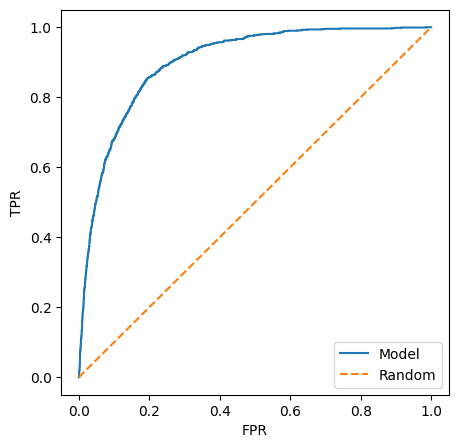

In [21]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

In [22]:
roc_auc_score(y_val, y_pred).round(3)

0.9

## **Precision and Recall**

In [23]:
def precision_recall_dataframe(y_val, y_pred):
    scores = []
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['precision'] = df_scores.fp / (df_scores.fp + df_scores.tp)
    
    return df_scores

In [24]:
df_metrics = precision_recall_dataframe(y_val, y_pred)
df_metrics.head()

,threshold,tp,fp,fn,tn,recall,precision
0,0.00,1098,7944,0,0,1.000000,0.878567
1,0.01,1094,7002,4,942,0.996357,0.864872
2,0.02,1093,5787,5,2157,0.995446,0.841134
3,0.03,1087,4743,11,3201,0.989982,0.813551
4,0.04,1069,3798,29,4146,0.973588,0.780358


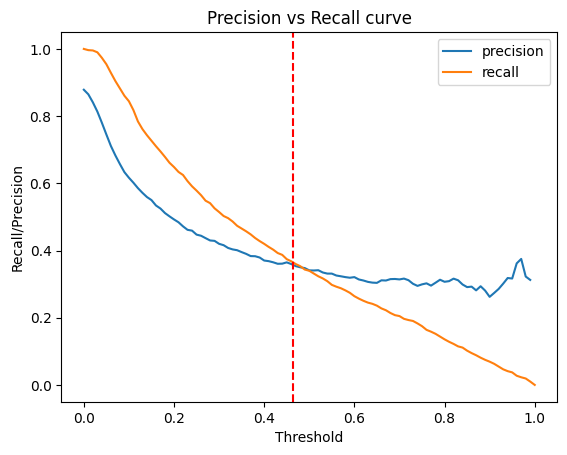

In [25]:
plt.plot(df_metrics.threshold, df_metrics['precision'], label='precision')
plt.plot(df_metrics.threshold, df_metrics['recall'], label='recall')
plt.axvline(x=0.465, color='r', linestyle='--')
plt.title('Precision vs Recall curve')
plt.xlabel('Threshold')
plt.ylabel('Recall/Precision')
plt.legend()

## **F1-Score**

In [26]:
df_metrics['f1-score'] = 2*df_metrics['precision']*df_metrics['recall']/(df_metrics['precision'] + df_metrics['recall'])
df_metrics[::10]

,threshold,tp,fp,fn,tn,recall,precision,f1-score
0,0.0,1098,7944,0,0,1.000000,0.878567,0.935359
10,0.1,927,1491,171,6453,0.844262,0.616625,0.712708
20,0.2,712,691,386,7253,0.648452,0.492516,0.559828
30,0.3,565,409,533,7535,0.514572,0.419918,0.462451
40,0.4,461,271,637,7673,0.419854,0.370219,0.393477
50,0.5,373,193,725,7751,0.339709,0.340989,0.340348
60,0.6,290,137,808,7807,0.264117,0.320843,0.289729
70,0.7,225,103,873,7841,0.204918,0.314024,0.248002
80,0.8,149,66,949,7878,0.135701,0.306977,0.188205
90,0.9,76,27,1022,7917,0.069217,0.262136,0.109516


In [27]:
max_index = df_metrics['f1-score'].idxmax()
df_metrics.iloc[max_index, :]

threshold       0.000000
tp           1098.000000
fp           7944.000000
fn              0.000000
tn              0.000000
recall          1.000000
precision       0.878567
f1-score        0.935359
Name: 0, dtype: float64

## **5-Fold CV**

In [28]:
from sklearn.model_selection import KFold

In [29]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical_columns + numerical_columns].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [30]:
def predict(df, dv, model):
    dicts = df[categorical_columns + numerical_columns].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [31]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = []
for train_idx, val_idx in kfold.split(df_full_train):
    
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.y.values
    y_val = df_val.y.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print(f"AUC scores for each fold: {scores}")
print(f"fold mean: {np.mean(scores)}, std: {np.std(scores)}")

AUC scores for each fold: [0.8995656440318812, 0.8993077532546184, 0.9112583997605899, 0.9081050110170497, 0.9100220150411489]
fold mean: 0.9056517646210576, std: 0.005173764746199814


## **Question 6: Hyperparameter Tuning**

In [32]:
from tqdm.auto import tqdm

In [33]:
n_splits = 5

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.y.values
        y_val = df_val.y.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/3 [00:00<?, ?it/s]

C=1e-06 0.701 +- 0.009
C=0.001 0.861 +- 0.007
C=1 0.906 +- 0.005
